## Домашнее задание

В этом домашнем задании мы будем убирать шум из изображения. В качестве исходного изображения будем использовать https://en.wikipedia.org/wiki/Lenna . Делать мы это будем с помощью двумерного фурье преобразования.


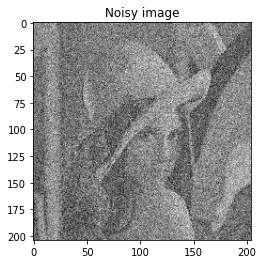

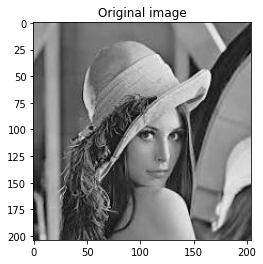

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
from scipy import fftpack
from skimage import io


def plot_spectrum(im_fft):
    from matplotlib.colors import LogNorm
    # A logarithmic colormap
    plt.imshow(np.abs(im_fft), norm=LogNorm(vmin=5))
    plt.colorbar()
    
# читаем изображение
image = io.imread('images.jpeg', as_gray=True)
# зашумляем его 
image_noisy = image + 0.25 * ss.norm().rvs(size=image.shape)
plt.figure()
plt.imshow(image_noisy, plt.cm.gray)
plt.title('Noisy image')
plt.show()

plt.figure()
plt.imshow(image, plt.cm.gray)
plt.title('Original image')
plt.show()

Здесь мы видим двумерное фурье преобразование. Его прелесть в том, что для реальных обычных фотографий основная энергия его
будет сосредоточена по углам - это отвечает низким частотам. Чем ближе к центру - тем больше частота

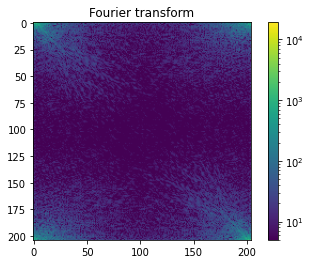

In [2]:
im_fft_true = fftpack.fft2(image)

plt.figure()
plot_spectrum(im_fft_true)
plt.title('Fourier transform')
plt.show()


Фурье преобразование зашумленного изображения добавляет куда больше энергии высоким частотам, т.е. тем, которые ближе к центру.
Избавление от шума происходит следующим образом: мы оставляем низкочастотные колебания, т.е. углы, и зануляем высокочастотные, т.е. все, что в середине. 

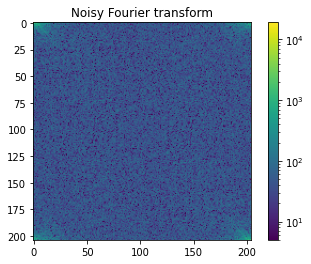

In [3]:

im_fft = fftpack.fft2(image_noisy)

plt.figure()
plot_spectrum(im_fft)
plt.title('Noisy Fourier transform')
plt.show()

Для этого вам нужно получить его 2d фурье спектр и занулить все элементы фурье преобразования которые находятся вне углах. 
Это можно сделать разными способами, например, можно для каждого угла оставить только первые \textit{keep_fraction} процентов по ширине и длине.

In [4]:

keep_fraction = 0.1

im_fft2 = im_fft.copy()


r, c = im_fft2.shape

## YOUR CODE HERE

## YOUR CODE HERE

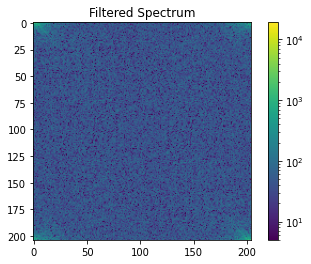

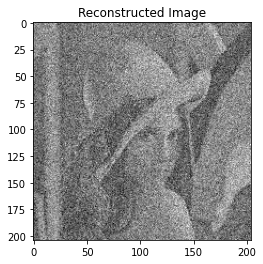

In [5]:
plt.figure()
plot_spectrum(im_fft2)
plt.title('Filtered Spectrum')
plt.show()


im_new = fftpack.ifft2(im_fft2).real

plt.figure()
plt.imshow(im_new, plt.cm.gray)
plt.title('Reconstructed Image')
plt.show()

In [6]:
rmse = lambda x, y: np.sqrt(np.mean((x - y) ** 2))

assert rmse(im_new, image) < 0.12, "Изображение слишком шумное. 

SyntaxError: unterminated string literal (detected at line 3) (4134095065.py, line 3)